## Data Objects Used in the Trading Pipeline

The main inputs are organised into three groups:

1. **Market data panels**: prices, public traded volume, and alpha signals.
2. **Model parameter tables**: scaling parameters and fitted impact parameters.
3. **Strategy objects**: alpha dictionaries, trade dictionaries, and final backtest outputs.

---

<table>
<tr>
<td width="50%">

### A. Panel DataFrames

| Object | Index | Columns | Values | Used for |
|---|---|---|---|---|
| `test_px_df` | `(stock, date)` | Intraday time bins | Mid prices | Backtesting and return calculation |
| `test_traded_volume_df` | `(stock, date)` | Intraday time bins | Public signed volume | Public impact adjustment |
| `synthetic_alpha_df` | `(stock, date)` | Intraday time bins | Intraday alpha | OW optimal strategy |
| `strategy_trades_df` | `(stock, date)` | Intraday time bins | Signed strategy trades | Backtest input |

All of these objects have the same basic panel structure:

```text
index   = MultiIndex(stock, date)
columns = intraday time bins
values  = price / volume / alpha / trade

### B. Parameter DataFrames

| Object | Index | Relevant columns | Meaning |
|---|---|---|---|
| `scaling_df` | `stock` | `ADV`, `sigma` | Stock-level liquidity and volatility scaling |
| `stock_results_df` | default integer index | all model / half-life fits | Raw impact model fitting output |
| `best_df` | default integer index | best half-life by model | Selects the best half-life for each impact model |
| `fit_df` | `stock` | `lambda_hat`, `half_life_seconds` | Fitted parameters for one chosen impact model |

`fit_df` is created from:

```text
impact_model_stock_results_201901_train_201902_test.csv
impact_model_best_by_is_201901_train_201902_test.csv

stock_results_df = all stock-level fits for all models and all half-lives
best_df          = selected best half-life for each model
fit_df           = stock-level fitted parameters for one model at its best half-life

## Dictionaries Created Before Running the Pipeline

Before passing the objects into the trading/backtesting pipeline, we organise them into three dictionaries:

1. `fit_dfs` — fitted impact model parameters  
2. `alpha_dfs` — alpha signal panels  
3. `strategy_trade_dfs` — strategy trade panels  

---

### 1. Fitted Impact Model Dictionary

```python
fit_dfs = {
    "ow": ow_fit_df,
    "afs": afs_fit_df,
    "reduced_form": reduced_fit_df,
}
```

| Key | DataFrame | Index | Main columns | Meaning |
|---|---|---|---|---|
| `"ow"` | `ow_fit_df` | `stock` | `lambda_hat`, `half_life_seconds` | Fitted OW impact parameters |
| `"afs"` | `afs_fit_df` | `stock` | `lambda_hat`, `half_life_seconds` | Fitted AFS-style impact parameters |
| `"reduced_form"` | `reduced_fit_df` | `stock` | `lambda_hat`, `half_life_seconds` | Fitted reduced-form impact parameters |

Each dataframe has the same structure:

```text
index   = stock
columns = lambda_hat, half_life_seconds, model_type, is_r2, oos_r2, ...
```

---

### 2. Alpha Signal Dictionary

```python
alpha_dfs = {
    "intraday_only": synthetic_alpha_df,
    "night_only": overnight_alpha_df,
    "combined": combined_alpha_df,
}
```

| Key | DataFrame | Index | Columns | Values |
|---|---|---|---|---|
| `"intraday_only"` | `synthetic_alpha_df` | `(stock, date)` | intraday time bins | intraday alpha |
| `"night_only"` | `overnight_alpha_df` | `(stock, date)` | intraday time bins | overnight alpha repeated through the day |
| `"combined"` | `combined_alpha_df` | `(stock, date)` | intraday time bins | intraday + overnight alpha |

Each alpha dataframe has the same panel structure:

```text
index   = MultiIndex(stock, date)
columns = intraday time bins
values  = alpha signal
```

The alpha signal itself is not model-specific. The same intraday alpha can be passed into different impact-model backtests. The model-specific distinction appears later in the trade/backtest dictionaries.

---

### 3. Strategy Trade Dictionaries

Because the project separates **daily-reset** and **rolling/carry** backtests, the strategy trades are organised into two dictionaries.

---

#### A. Non-Rolling / Daily-Reset Strategy Trades

```python
non_rolling_strategy_trade_dfs = {
    "non_rolling_ow_day_only": ow_day_only_trades_df,
    "non_rolling_afs_day_only": afs_day_only_trades_df,
    "non_rolling_reduced_day_only": reduced_day_only_trades_df,
}
```

| Key | DataFrame | Index | Columns | Values |
|---|---|---|---|---|
| `"non_rolling_ow_day_only"` | `ow_day_only_trades_df` | `(stock, date)` | intraday time bins | OW optimal day-only trades |
| `"non_rolling_afs_day_only"` | `afs_day_only_trades_df` | `(stock, date)` | intraday time bins | AFS optimal day-only trades |
| `"non_rolling_reduced_day_only"` | `reduced_day_only_trades_df` | `(stock, date)` | intraday time bins | Reduced-form optimal day-only trades |

These strategies reset position and impact state at the beginning of each day.

---

#### B. Rolling / Carry Strategy Trades

```python
rolling_strategy_trade_dfs = {
    "rolling_ow_day_only": rolling_ow_day_only_trades_df,
    "rolling_afs_day_only": rolling_afs_day_only_trades_df,
    "rolling_reduced_day_only": rolling_reduced_day_only_trades_df,
    "rolling_ow_night_only": rolling_ow_night_only_trades_df,
    "rolling_ow_combined": rolling_ow_combined_trades_df,
}
```

| Key | DataFrame | Index | Columns | Values |
|---|---|---|---|---|
| `"rolling_ow_day_only"` | `rolling_ow_day_only_trades_df` | `(stock, date)` | intraday time bins | Rolling OW day-only trades |
| `"rolling_afs_day_only"` | `rolling_afs_day_only_trades_df` | `(stock, date)` | intraday time bins | Rolling AFS day-only trades |
| `"rolling_reduced_day_only"` | `rolling_reduced_day_only_trades_df` | `(stock, date)` | intraday time bins | Rolling reduced-form day-only trades |
| `"rolling_ow_night_only"` | `rolling_ow_night_only_trades_df` | `(stock, date)` | intraday time bins | Rolling OW trades from overnight alpha |
| `"rolling_ow_combined"` | `rolling_ow_combined_trades_df` | `(stock, date)` | intraday time bins | Rolling OW trades from intraday + overnight alpha |

These strategies carry position and impact state across days.

---

Each trade dataframe has the same panel structure:

```text
index   = MultiIndex(stock, date)
columns = intraday time bins
values  = signed trade q
```

In total, this gives eight strategy variants:

| Group | Strategies |
|---|---|
| Non-rolling day-only | OW, AFS, reduced-form |
| Rolling day-only | OW, AFS, reduced-form |
| Rolling overnight extension | OW night-only, OW combined |

 ## 1. Imports and paths

In [160]:
import pandas as pd
import numpy as np
import importlib

from src.overnight_carry_backtest import *

DATA_DIR = "data"

import src.synthetic_alphas as synthetic_alphas
import src.optimal_trading_strategy as optimal_trading_strategy
import src.backtest_engine as backtest_engine
import src.performance_metrics as performance_metrics
import src.overnight_carry_backtest as overnight_carry_backtest

importlib.reload(synthetic_alphas)
importlib.reload(optimal_trading_strategy)
importlib.reload(backtest_engine)
importlib.reload(overnight_carry_backtest)
importlib.reload(performance_metrics)

from src.synthetic_alphas import *
from src.optimal_trading_strategy import *
from src.backtest_engine import *
from src.performance_metrics import *
from src.overnight_carry_backtest import *

## 2. Load core market data

In [74]:
test_px_df = load_panel_csv(
    f"{DATA_DIR}/test_px_201902_20.csv"
)

test_traded_volume_df = load_panel_csv(
    f"{DATA_DIR}/test_traded_volume_201902_20.csv"
)

scaling_df = load_stock_level_csv(
    f"{DATA_DIR}/scaling_201901_20.csv"
)

## 3. Load fitted impact model outputs

In [75]:
# %%
stock_results_df = pd.read_csv(
    f"{DATA_DIR}/impact_model_stock_results_201901_train_201902_test.csv"
)

best_df = pd.read_csv(
    f"{DATA_DIR}/impact_model_best_by_is_201901_train_201902_test.csv"
)

ow_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="ow",
)

afs_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="afs",
)

reduced_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="reduced_form",
)

## 4. Create fitted impact model dictionary

In [76]:
fit_dfs = {
    "ow": ow_fit_df,
    "afs": afs_fit_df,
    "reduced_form": reduced_fit_df,
}

## 5. Load and create alpha panels

In [ ]:
synthetic_alpha_df = load_panel_csv(
    f"{DATA_DIR}/synthetic_alpha_201902_20.csv"
)

synthetic_alpha_mu_df = load_panel_csv(
    f"{DATA_DIR}/synthetic_alpha_decay_201902_20.csv"
)

alpha_dfs = {
    "intraday_only": synthetic_alpha_df,
}

In [80]:
# EXAMINE BETTER WHAT THIS FUNCTION IS CREATING

overnight_alpha_df, overnight_return_s = make_next_open_overnight_alpha_panel(
    test_px_df=test_px_df,
    overnight_alpha_level=1.0,
)

combined_alpha_df = make_combined_alpha_df(
    intraday_alpha_df=synthetic_alpha_df,
    overnight_alpha_df=overnight_alpha_df,
    intraday_weight=1.0,
    overnight_weight=1.0,
)

## 7. Load non-rolling / daily-reset strategy trades

In [81]:
# ------------------------------------------------------------
# Load final strategy trades from 2.5
# ------------------------------------------------------------

ow_day_only_trades_df = load_panel_csv(
    f"{DATA_DIR}/strategy_trades_non_rolling_ow_day_only_201902_20.csv"
)

# STILL NOT AVAILABLE
afs_day_only_trades_df = load_panel_csv(
    f"{DATA_DIR}/strategy_trades_non_rolling_afs_day_only_201902_20.csv"
)

reduced_day_only_trades_df = load_panel_csv(
    f"{DATA_DIR}/strategy_trades_non_rolling_reduced_day_only_201902_20.csv"
)

strategy_trade_dfs = {
    "ow_optimal": ow_day_only_trades_df,
    "afs_optimal": afs_day_only_trades_df,
    "reduced_form_optimal": reduced_day_only_trades_df,
}

# Same object under the older name used by some of your existing cells
non_rolling_strategy_trade_dfs = strategy_trade_dfs

In [138]:
# ------------------------------------------------------------
# Load target impact paths from 2.5
# ------------------------------------------------------------

ow_day_only_target_impact_df = load_panel_csv(
    f"{DATA_DIR}/strategy_target_impact_non_rolling_ow_day_only_201902_20.csv"
)

afs_day_only_target_impact_df = load_panel_csv(
    f"{DATA_DIR}/strategy_target_impact_non_rolling_afs_day_only_201902_20.csv"
)

reduced_day_only_target_impact_df = load_panel_csv(
    f"{DATA_DIR}/strategy_target_impact_non_rolling_reduced_day_only_201902_20.csv"
)

strategy_target_impact_dfs = {
    "ow_optimal": ow_day_only_target_impact_df,
    "afs_optimal": afs_day_only_target_impact_df,
    "reduced_form_optimal": reduced_day_only_target_impact_df,
}

## 10. Loading Rolling strategies

In [83]:
# rolling_strategy_trade_dfs = {
#     "rolling_ow_day_only": rolling_ow_day_only_trades_df,
#     "rolling_afs_day_only": rolling_afs_day_only_trades_df,
#     "rolling_reduced_day_only": rolling_reduced_day_only_trades_df,
#     "rolling_ow_night_only": rolling_ow_night_only_trades_df,
#     "rolling_ow_combined": rolling_ow_combined_trades_df,
# }

# **PLOTS**

### **Alpha Correlation with returns**

$$
\rho_i^{(h)}
=
\mathrm{Corr}
\left(
\alpha_{i,d,j},
\frac{P_{i,d,j+h}-P_{i,d,j}}{P_{i,d,j}}
\right)
$$

In [110]:
alpha_corr_intraday_10s = alpha_forward_return_corr(
    alpha_df=alpha_dfs["intraday_only"],
    px_df=test_px_df,
    horizon_bins=1
)

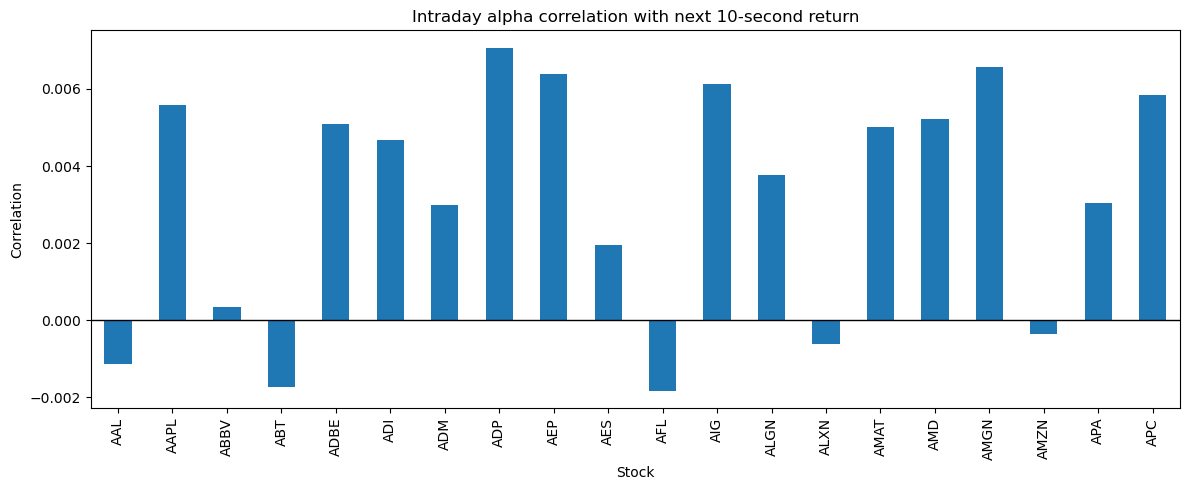

In [111]:
# Compute alpha return correlation by stock

plot_alpha_corr_by_stock(
    alpha_corr_intraday_10s,
    title="Intraday alpha correlation with next 10-second return"
)

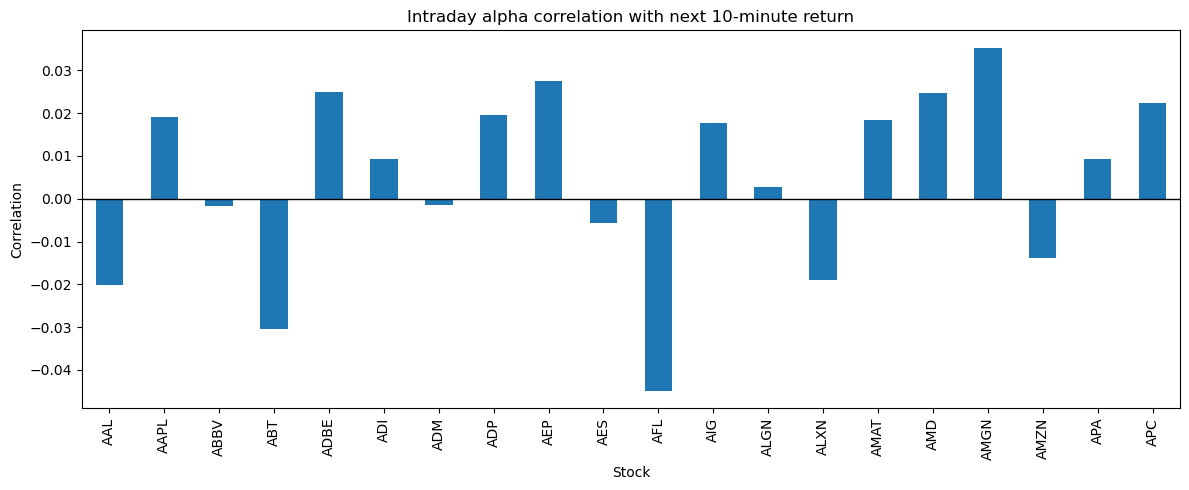

In [113]:
alpha_corr_intraday_10min = alpha_forward_return_corr(
    alpha_df=alpha_dfs["intraday_only"],
    px_df=test_px_df,
    horizon_bins=60
)

plot_alpha_corr_by_stock(
    alpha_corr_intraday_10min,
    title="Intraday alpha correlation with next 10-minute return"
)

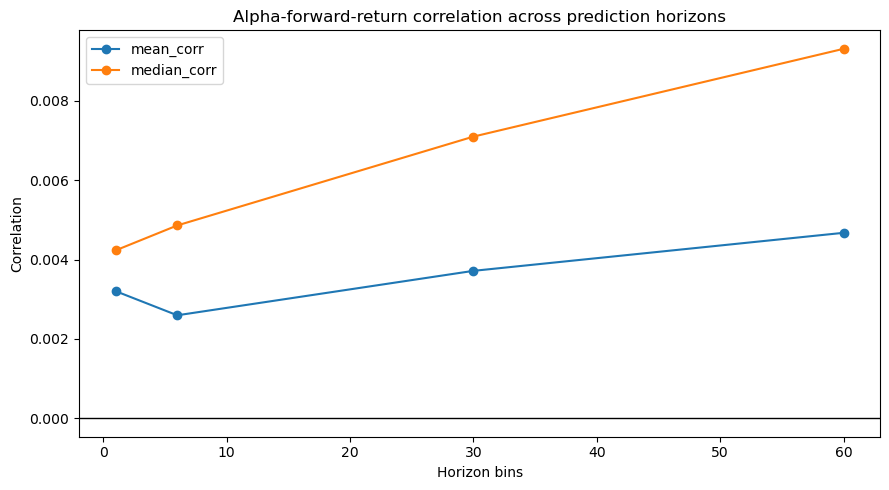

In [142]:
# plot correlation across horizons
horizon_df = plot_alpha_corr_by_horizon(
    alpha_df=alpha_dfs["intraday_only"],
    px_df=test_px_df,
    horizon_bins_list=[1, 6, 30, 60]
)

### What the plot shows

The correlations are **positive at all horizons**, so the alpha has the correct sign on average: higher alpha tends to be followed by positive future returns. But the correlations are very small, around $0.003$ to $0.009$, so this is not a strong alpha-return relationship. It is directionally positive, but weak.

The median correlation is higher than the mean correlation. That usually means most stocks have mildly positive correlations, but some bad/negative stocks drag down the average. This is useful because it tells us the alpha is not equally good across all stocks.

### The surprising part

The correlation increases with horizon: $10s < 5min < 10min$. At first this looks strange, because the synthetic alpha was generated using the next-bin return. But we are not correlating the synthetic return innovation with future returns. We are correlating the **cumulative alpha path**, $\alpha_t = \sum_{s \leq t} \tilde r_s$, with future returns. A cumulative alpha path is smoother and more trend-like, so it may line up better with longer-horizon price moves than with one noisy 10-second return. Therefore, the rising line is not impossible.

The alpha’s average correlation improves at longer horizons, but this improvement is not uniform across stocks. Some names benefit strongly from the longer horizon, while others become negatively correlated. Therefore, the longer-horizon alpha relationship is less stable stock-by-stock.

# **P&L**

In [117]:
daily_portfolio_df = build_daily_portfolio_df(all_model_comparison_df)
performance_summary_df = summarize_strategy_performance(daily_portfolio_df)

In [122]:
matched_pairs = {
    "ow": "ow_optimal",
    "afs": "afs_optimal",
    "reduced_form": "reduced_form_optimal",
}

matched_daily_df = pd.concat([
    daily_portfolio_df[
        (daily_portfolio_df["backtest_model"] == model)
        & (daily_portfolio_df["strategy"] == strategy)
    ]
    for model, strategy in matched_pairs.items()
])

matched_daily_df = matched_daily_df.sort_values(["backtest_model", "date"])
matched_performance_df = summarize_strategy_performance(matched_daily_df)

### **Daily P&L**

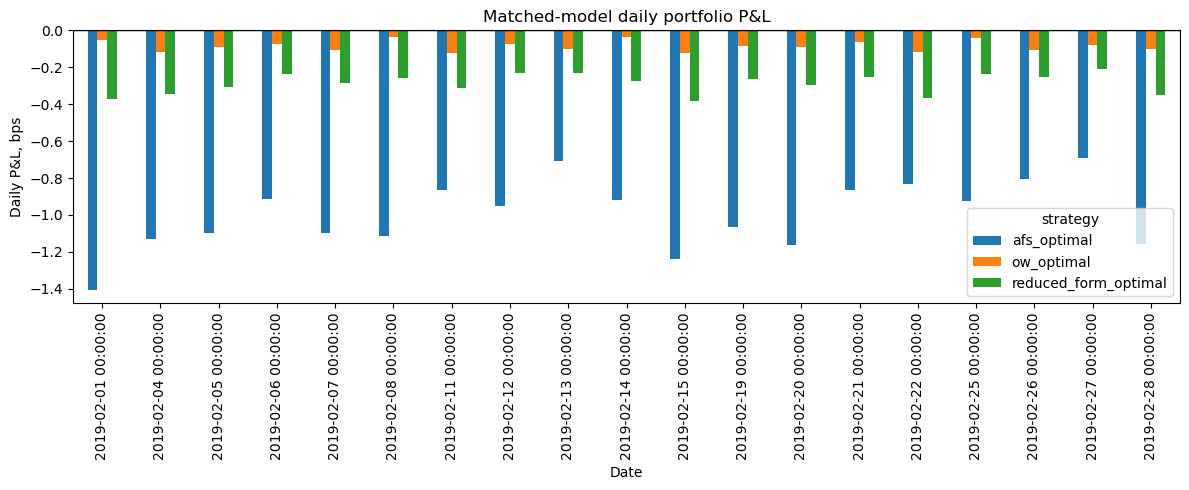

In [123]:
pivot_daily_pnl = matched_daily_df.pivot_table(
    index="date",
    columns="strategy",
    values="pnl_bps",
    aggfunc="sum"
).sort_index()

pivot_daily_pnl.plot(
    kind="bar",
    figsize=(12, 5),
    title="Matched-model daily portfolio P&L"
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Daily P&L, bps")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### **Cummulative P&L all stocks together**

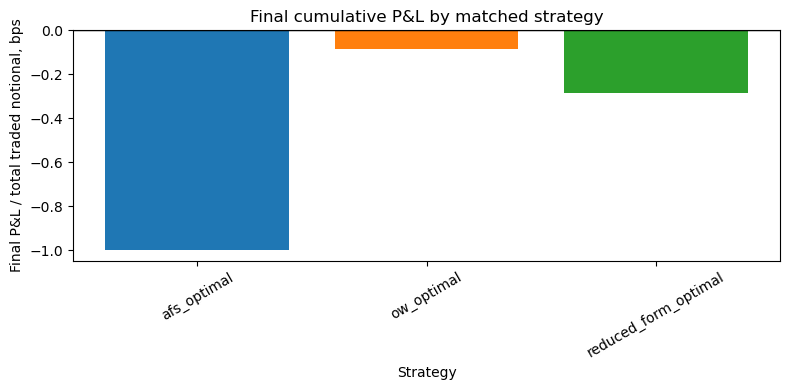

In [135]:
matched_final_pnl_df = plot_final_pnl_by_strategy(
    daily_df=matched_daily_df,
    use_bps=True,
    title="Final cumulative P&L by matched strategy"
)

### **Cummulative P&L by stock**

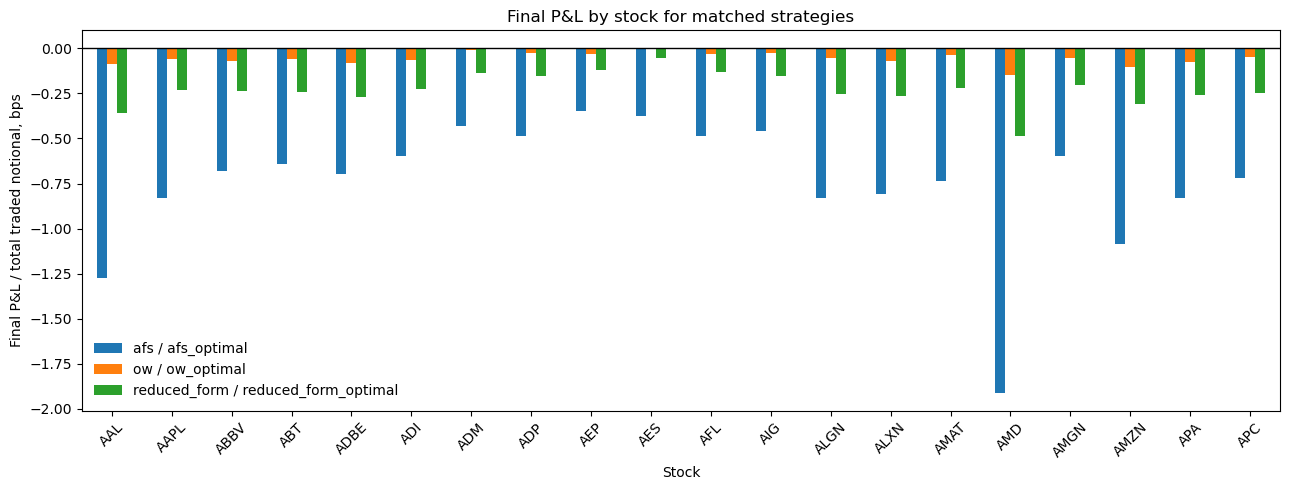

In [131]:
matched_stock_pnl_df = plot_matched_final_pnl_by_stock(
    backtest_results_df=all_model_comparison_df,
    use_bps=True,
)

### **Cummulative daily P&L**

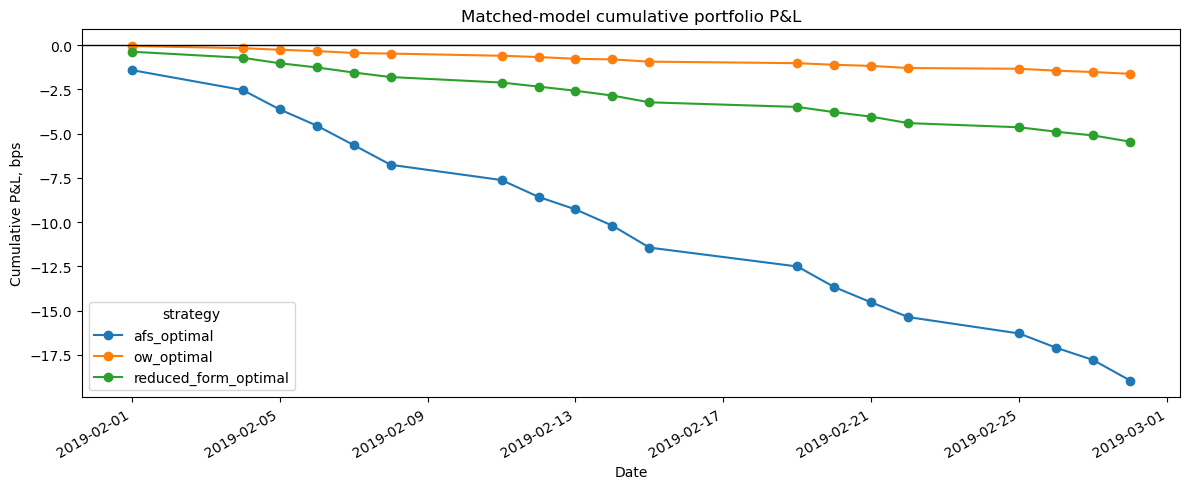

In [124]:
pivot_daily_pnl.cumsum().plot(
    figsize=(12, 5),
    marker="o",
    title="Matched-model cumulative portfolio P&L"
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Cumulative P&L, bps")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### **Hourly P&L**

c:\Users\maria\Quant_Trading_Price_Impact\src\performance_metrics.py:373: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(intraday_df["time"], errors="coerce")


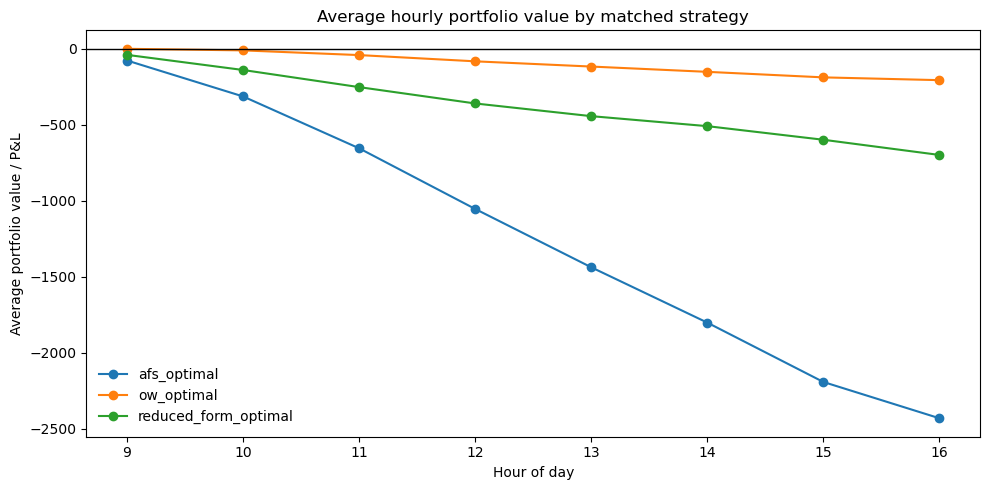

In [141]:
hourly_portfolio_df = plot_hourly_portfolio_value_matched_strategies(
    strategy_trade_dfs=strategy_trade_dfs,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
)

### **Cumulative P&L comparison by simulator**

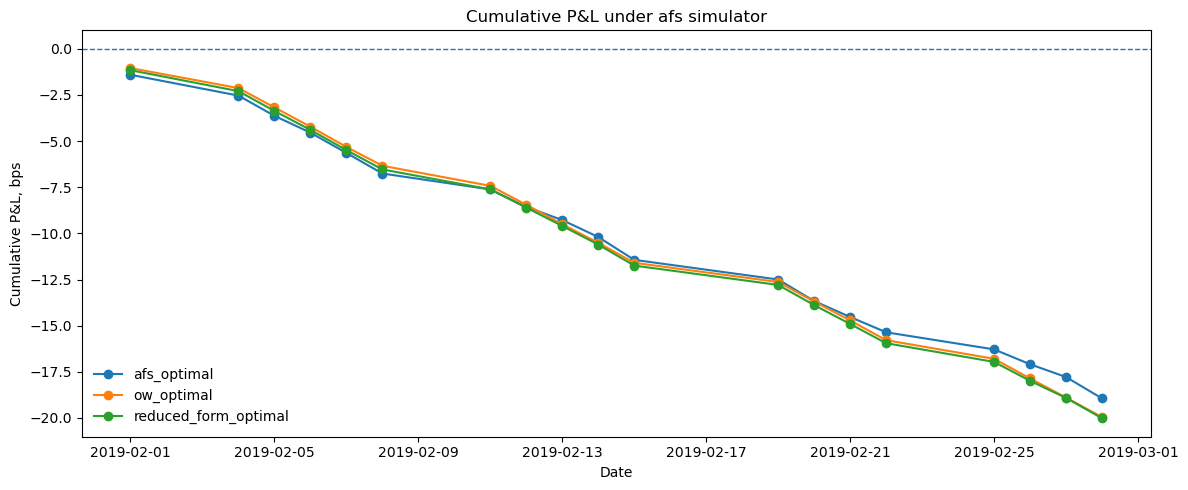

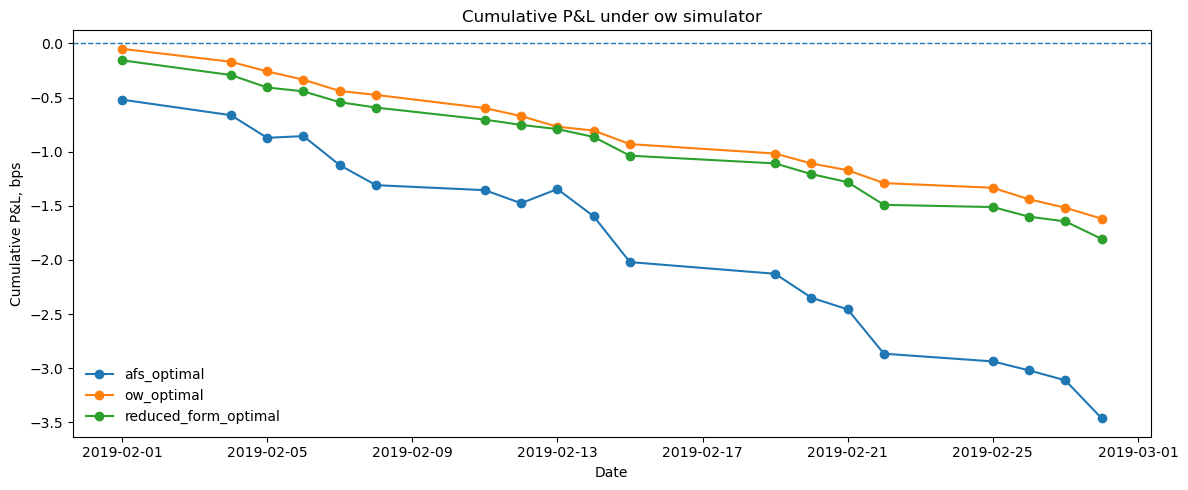

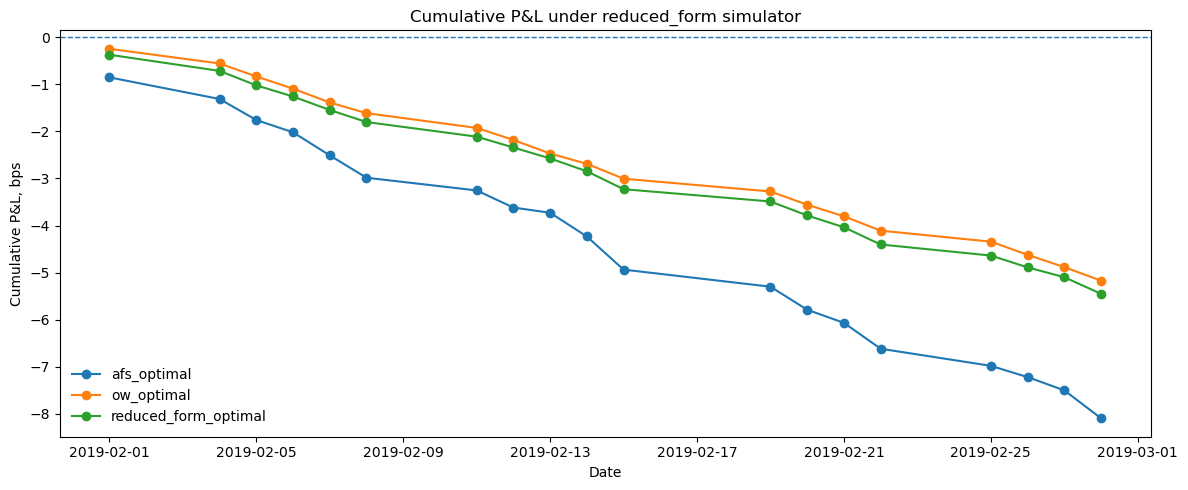

In [119]:
for model in daily_portfolio_df["backtest_model"].unique():
    plot_cumulative_pnl_by_model(
        daily_portfolio_df=daily_portfolio_df,
        backtest_model=model
    )

### **P&L for a specific stock and day**

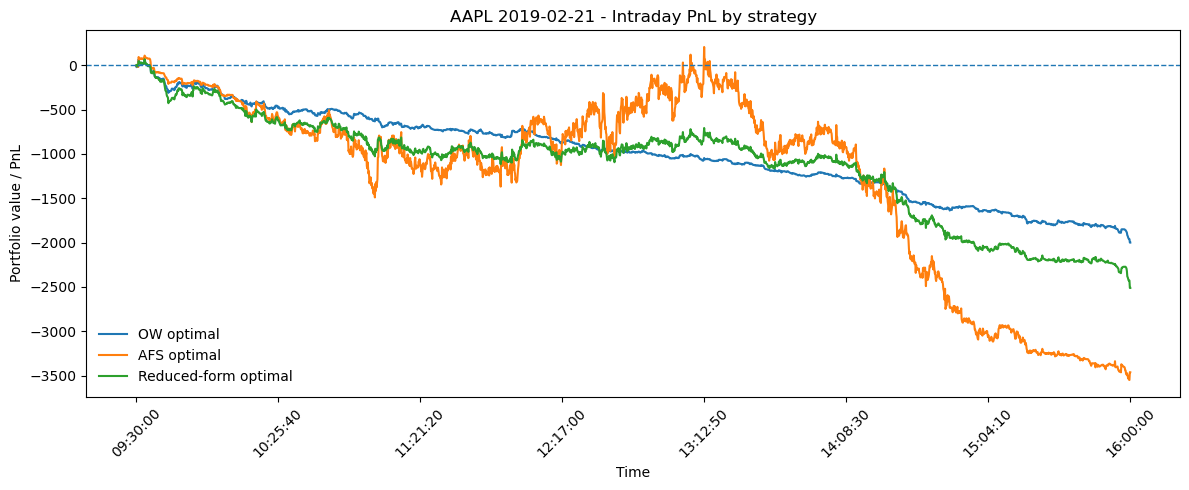

In [143]:
stock = "AAPL"
date = "2019-02-21"

paths, summaries = run_one_stock_day_paths_for_strategies(
    stock=stock,
    date=date,
    strategy_trade_dfs={
        "OW optimal": ow_day_only_trades_df,
        "AFS optimal": afs_day_only_trades_df,
        "Reduced-form optimal": reduced_day_only_trades_df,
    },
    model_type="reduced_form",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
)

plot_one_stock_day_pnl_comparison(paths, stock, date)

## **IMPACT**

In [146]:
path_df, summary = run_one_stock_day_diagnostic(
    stock=stock,
    date=date,
    model_type="ow",
    test_px_df=test_px_df,
    strategy_trades_df=strategy_trade_dfs["ow_optimal"],
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
    plot=False,
)
target_impact = strategy_target_impact_dfs["ow_optimal"].loc[(stock, date)]
realized_impact = path_df["impact_in_price"] / path_df["mid_price"] # Converting to return units

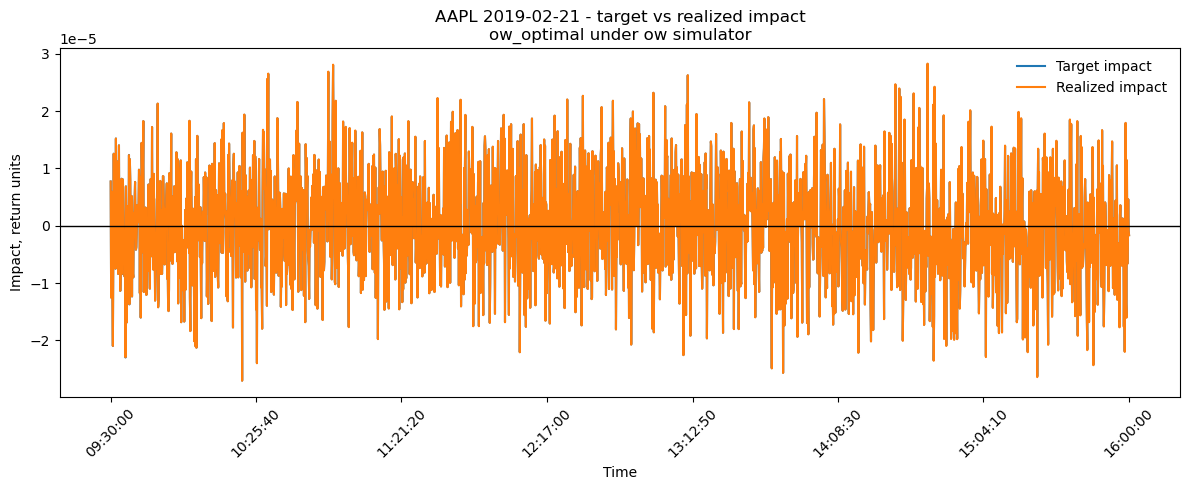

In [148]:
plot_target_vs_realized_impact(
    target_impact=target_impact,
    path_df=path_df,
    stock=stock,
    date=date,
    strategy_name="ow_optimal",
    model_type="ow",
)

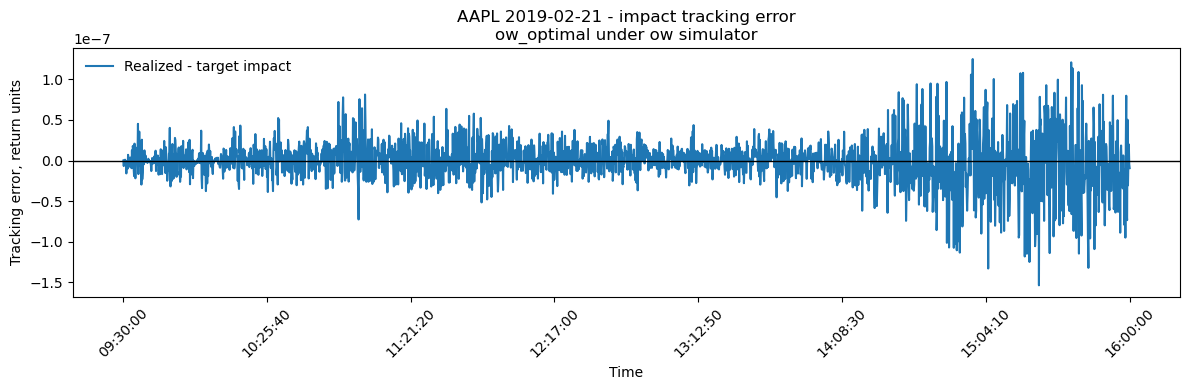

{'mean_error': np.float64(-1.0373746255896298e-09),
 'mean_abs_error': np.float64(1.9295806089623548e-08),
 'rmse': np.float64(2.8333848799112643e-08),
 'max_abs_error': 1.5353168321363033e-07}

In [151]:
tracking_error, tracking_error_stats = plot_impact_tracking_error(
    target_impact=target_impact,
    path_df=path_df,
    stock=stock,
    date=date,
    strategy_name="ow_optimal",
    model_type="ow",
)

tracking_error_stats

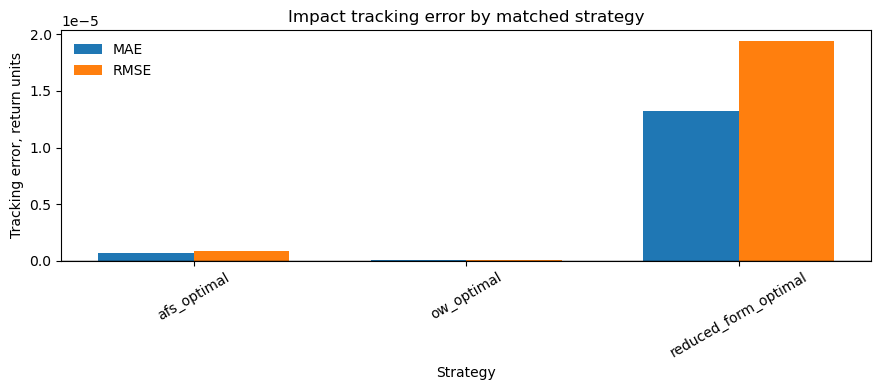

,backtest_model,strategy,mean_error,mean_mae,mean_rmse,max_abs_error,n_stock_days
0,afs,afs_optimal,-9.756061e-08,6.530603e-07,8.809868e-07,0.000027,380
1,ow,ow_optimal,-2.399325e-09,6.238212e-08,8.507022e-08,0.000002,380
2,reduced_form,reduced_form_optimal,-9.193402e-08,1.325473e-05,1.939608e-05,0.000713,380


In [153]:
tracking_df, tracking_summary_df = compare_impact_tracking_by_strategy(
    strategy_trade_dfs=strategy_trade_dfs,
    strategy_target_impact_dfs=strategy_target_impact_dfs,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
)

tracking_summary_df

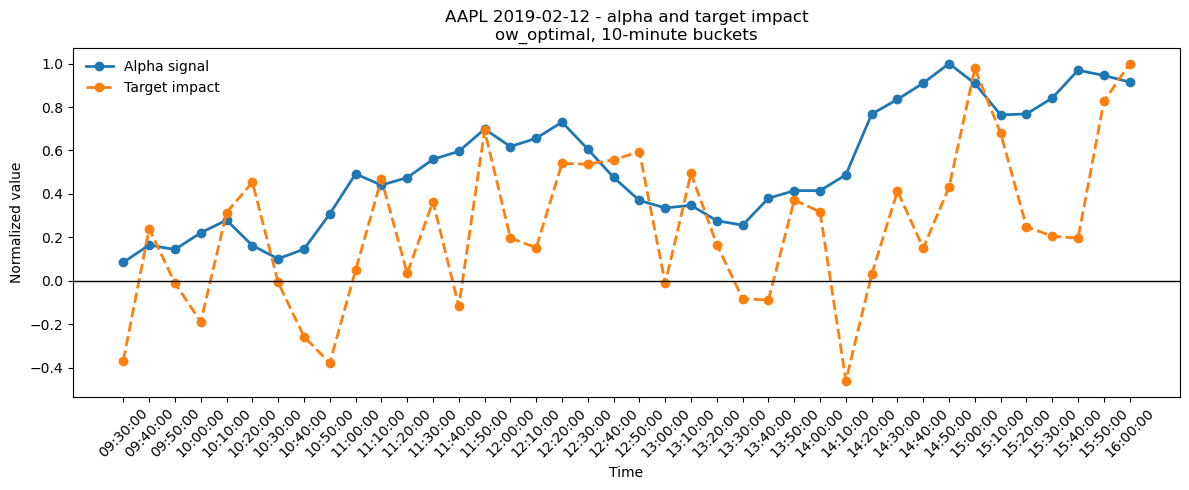

In [157]:
alpha_target_plot_df = plot_alpha_and_target_impact(
    alpha_df=alpha_dfs["intraday_only"],
    target_impact_df=strategy_target_impact_dfs["ow_optimal"],
    stock="AAPL",
    date="2019-02-12",
    strategy_name="ow_optimal",
    normalize=True,
    bucket_size=60,
)

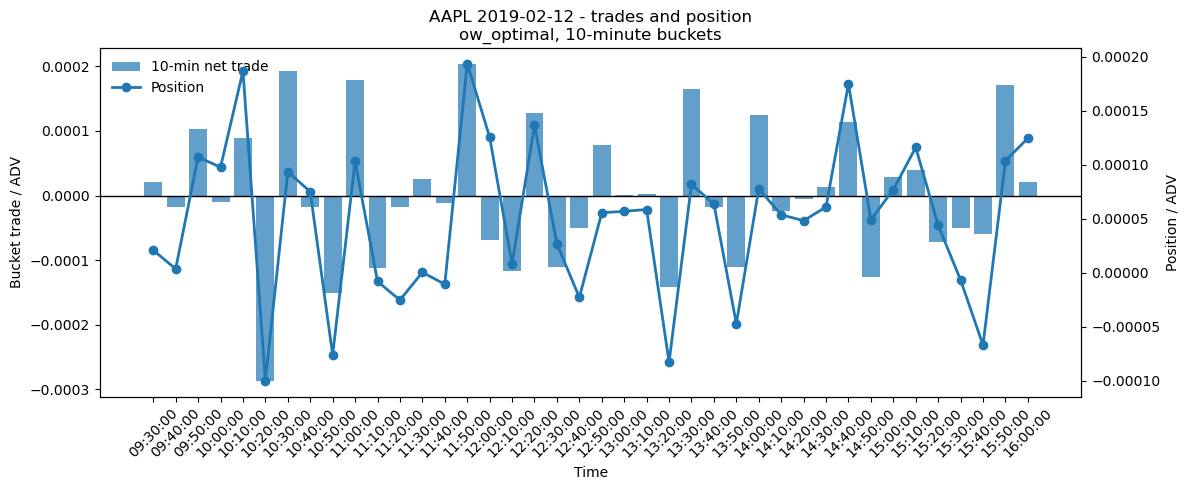

In [159]:
trade_position_df = plot_trades_and_position(
    trades_df=strategy_trade_dfs["ow_optimal"],
    stock="AAPL",
    date="2019-02-12",
    strategy_name="ow_optimal",
    bucket_size=60,
    scaling_df=scaling_df,
)

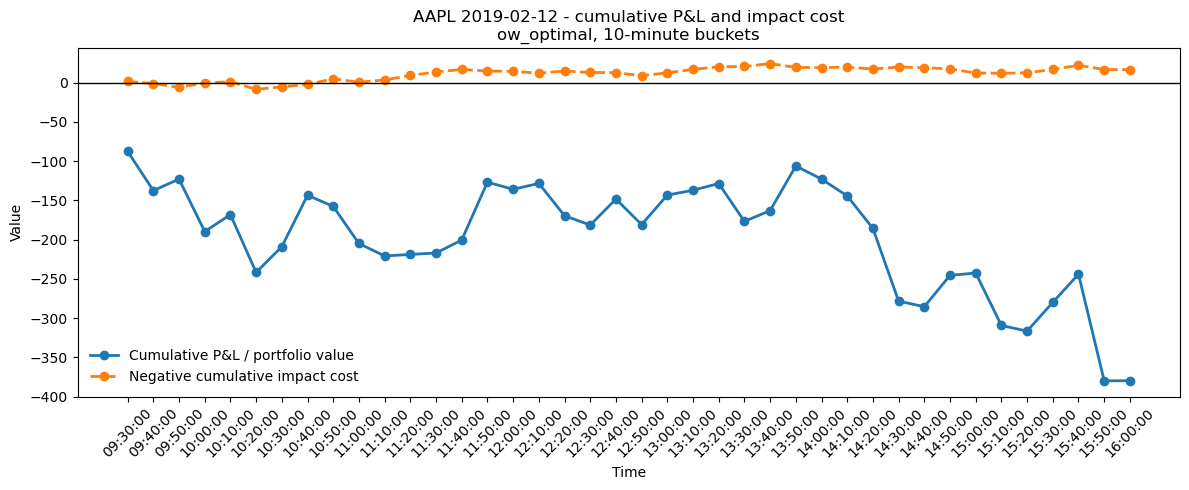

In [161]:
pnl_cost_df = plot_cumulative_pnl_and_impact_cost(
    path_df=path_df,
    stock="AAPL",
    date="2019-02-12",
    strategy_name="ow_optimal",
    trades_series=strategy_trade_dfs["ow_optimal"].loc[("AAPL", "2019-02-12")],
    bucket_size=60,
)

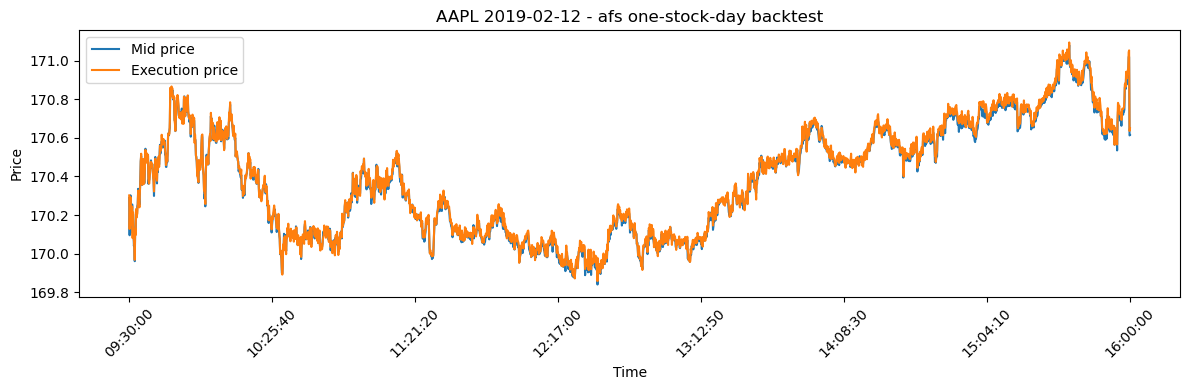

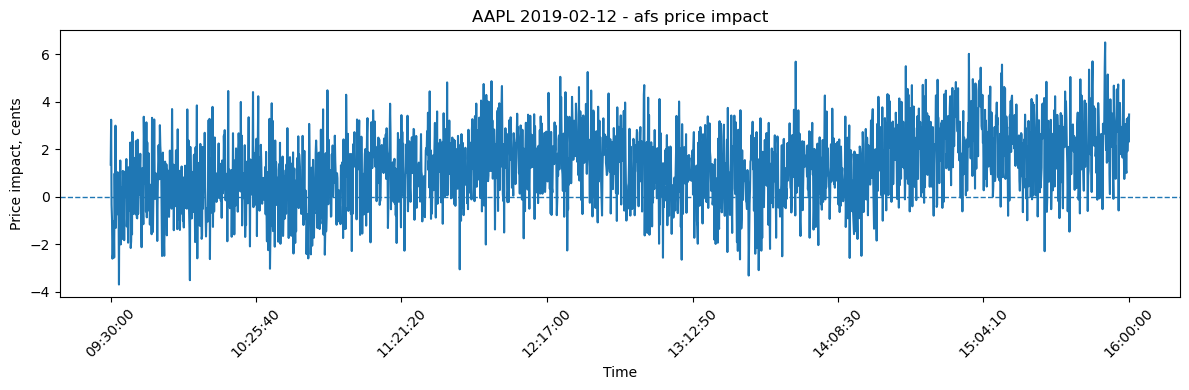

In [164]:
stock = "AAPL"
date = "2019-02-12"
model_type = "afs"
strategy_name = "afs_optimal"

path_df, summary = run_one_stock_day_diagnostic(
    stock=stock,
    date=date,
    model_type=model_type,
    test_px_df=test_px_df,
    strategy_trades_df=strategy_trade_dfs[strategy_name],
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
    plot=False,
)

plot_one_stock_day_backtest_path(
    path_df=path_df,
    stock=stock,
    date=date,
    model_type=model_type,
)

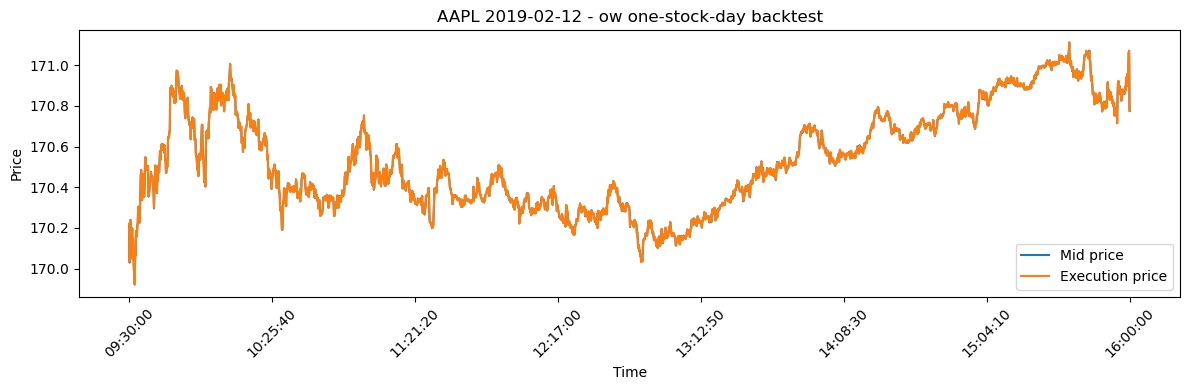

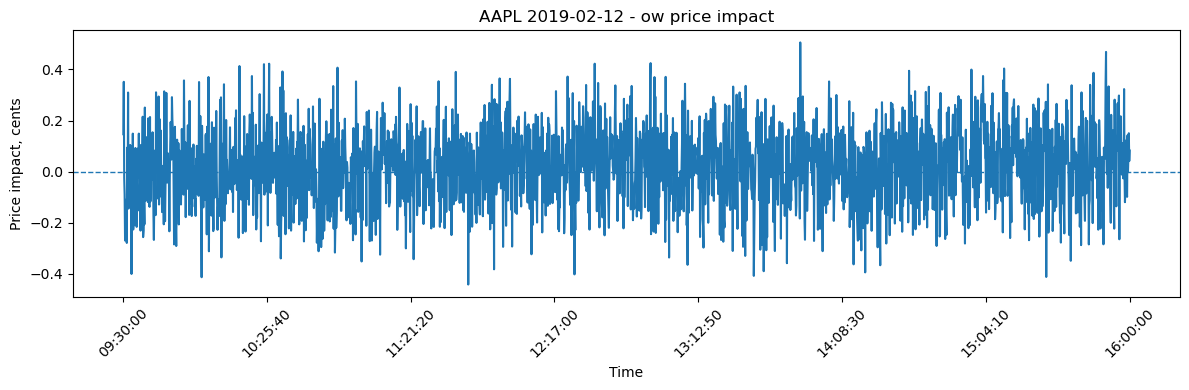

In [166]:
stock = "AAPL"
date = "2019-02-12"
model_type = "ow"
strategy_name = "ow_optimal"

path_df, summary = run_one_stock_day_diagnostic(
    stock=stock,
    date=date,
    model_type=model_type,
    test_px_df=test_px_df,
    strategy_trades_df=strategy_trade_dfs[strategy_name],
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
    plot=False,
)

plot_one_stock_day_backtest_path(
    path_df=path_df,
    stock=stock,
    date=date,
    model_type=model_type,
)

In [88]:
DT_SECONDS = 10
model_comparison_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=non_rolling_strategy_trade_dfs,
    model_type="reduced_form",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=DT_SECONDS,
)

display(model_comparison_df[
    (model_comparison_df["stock"] == "AAPL")
    & (model_comparison_df["date"].astype(str) == "2019-02-21")
][[
    "strategy",
    "daily_pnl",
    "impact_cost",
    "max_abs_impact",
    "final_position",
    "total_abs_traded",
    "net_traded",
    "model_type",
    "stock",
    "date",
]])

,strategy,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,model_type,stock,date
32,ow_optimal,-2000.503115,2539.667123,0.042788,-27.143271,593692.561905,-27.143271,reduced_form,AAPL,2019-02-21
412,afs_optimal,-3463.786112,3371.691212,0.049662,-385.897564,593692.561905,-385.897564,reduced_form,AAPL,2019-02-21
792,reduced_form_optimal,-2512.324541,2623.822551,0.026233,20.261165,593692.561905,20.261165,reduced_form,AAPL,2019-02-21


In [89]:
summary = (
    model_comparison_df
    .groupby("strategy")
    .agg(
        mean_pnl_bps=("pnl_bps", "mean"),
        median_pnl_bps=("pnl_bps", "median"),
        std_pnl_bps=("pnl_bps", "std"),
        mean_impact_cost_bps=("impact_cost_bps", "mean"),
        mean_max_abs_impact=("max_abs_impact", "mean"),
        mean_abs_traded=("total_abs_traded", "mean"),
    )
)

summary["daily_sharpe"] = summary["mean_pnl_bps"] / summary["std_pnl_bps"]

display(summary.round(4))

,mean_pnl_bps,median_pnl_bps,std_pnl_bps,mean_impact_cost_bps,mean_max_abs_impact,mean_abs_traded,daily_sharpe
strategy,,,,,,,
afs_optimal,-0.3386,-0.3067,0.5056,0.3410,0.0652,210496.521,-0.6697
ow_optimal,-0.2136,-0.2018,0.1038,0.2498,0.0580,210496.521,-2.0583
reduced_form_optimal,-0.2275,-0.2144,0.1884,0.2630,0.0412,210496.521,-1.2076


# 2.6 Performance metrics

In [91]:
strategy_trade_dfs = {
    "ow_optimal": ow_day_only_trades_df,
    "afs_optimal": afs_day_only_trades_df,
    "reduced_form_optimal": reduced_day_only_trades_df,
}

ow_sim_results = run_strategy_backtests_for_model(
    strategy_trade_dfs=strategy_trade_dfs,
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=DT_SECONDS,
)

afs_sim_results = run_strategy_backtests_for_model(
    strategy_trade_dfs=strategy_trade_dfs,
    model_type="afs",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=DT_SECONDS,
)

reduced_sim_results = run_strategy_backtests_for_model(
    strategy_trade_dfs=strategy_trade_dfs,
    model_type="reduced_form",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=DT_SECONDS,
)

all_model_comparison_df = pd.concat(
    [ow_sim_results, afs_sim_results, reduced_sim_results],
    ignore_index=True,
)

In [92]:
all_model_comparison_df.head()

,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,avg_price,traded_notional,model_type,stock,date,lambda_hat,ADV,sigma,half_life_seconds,impact_cost_bps,pnl_bps,strategy,backtest_model
0,-140.048380,82.472725,0.001413,86.497934,247344.466667,86.497934,36.441289,9.013551e+06,ow,AAL,2019-02-01,262.866026,1.236722e+06,0.000528,1800.0,0.091499,-0.155375,ow_optimal,ow
1,-133.174292,83.155577,0.001440,-5.951730,247344.466667,-5.951730,36.734744,9.086136e+06,ow,AAL,2019-02-04,262.866026,1.236722e+06,0.000528,1800.0,0.091519,-0.146569,ow_optimal,ow
2,-76.061284,84.725972,0.001231,-1.691696,247344.466667,-1.691696,37.059828,9.166543e+06,ow,AAL,2019-02-05,262.866026,1.236722e+06,0.000528,1800.0,0.092430,-0.082977,ow_optimal,ow
3,-44.664313,84.649282,0.001335,-62.322555,247344.466667,-62.322555,36.889794,9.124487e+06,ow,AAL,2019-02-06,262.866026,1.236722e+06,0.000528,1800.0,0.092772,-0.048950,ow_optimal,ow
4,-105.102887,83.213158,0.001113,57.820540,247344.466667,57.820540,36.449304,9.015534e+06,ow,AAL,2019-02-07,262.866026,1.236722e+06,0.000528,1800.0,0.092300,-0.116580,ow_optimal,ow


In [93]:
daily_portfolio_df = build_daily_portfolio_df(all_model_comparison_df)


performance_report_df = summarize_strategy_performance(daily_portfolio_df)
# performance_report_df["alpha_1bin_corr"] = alpha_corr_intraday
# performance_report_df["alpha_5min_corr"] = alpha_corr_5min
display(performance_report_df.round(4))

,backtest_model,strategy,expected_daily_pnl,expected_daily_pnl_bps,daily_pnl_vol,daily_pnl_vol_bps,daily_sharpe,annualized_sharpe,mean_transaction_cost,mean_transaction_cost_bps,max_daily_drawdown,max_daily_drawdown_bps,max_impact_dislocation,mean_impact_dislocation,mean_total_abs_traded,mean_net_traded,n_days
0,afs,afs_optimal,-48610.2272,-0.9969,9046.6612,0.1875,-5.3172,-84.4078,49129.6612,1.0071,-855102.1000,-17.5345,0.8589,0.7158,4209930.419,3231.2887,19
1,afs,ow_optimal,-51235.2630,-1.0503,1313.7285,0.0269,-39.0620,-620.0906,52352.0346,1.0732,-922615.5954,-18.9117,0.4836,0.4472,4209930.419,149.4243,19
2,afs,reduced_form_optimal,-51384.3895,-1.0535,2784.6150,0.0589,-17.8953,-284.0793,52965.5693,1.0858,-919885.2708,-18.8574,0.5858,0.5207,4209930.419,1232.0025,19
3,ow,afs_optimal,-8879.8690,-0.1822,7872.7799,0.1613,-1.1294,-17.9279,7746.0978,0.1588,-143358.1369,-2.9421,0.4250,0.3021,4209930.419,3231.2887,19
4,ow,ow_optimal,-4156.9558,-0.0852,1421.0072,0.0292,-2.9177,-46.3173,5356.3436,0.1098,-76538.0406,-1.5687,0.1081,0.0882,4209930.419,149.4243,19
5,ow,reduced_form_optimal,-4633.9102,-0.0950,2586.4439,0.0529,-1.7958,-28.5069,5772.3908,0.1183,-80416.7362,-1.6489,0.1568,0.1302,4209930.419,1232.0025,19
6,reduced_form,afs_optimal,-20772.3565,-0.4261,8574.5856,0.1763,-2.4164,-38.3584,20417.0041,0.4185,-353236.3895,-7.2450,0.9487,0.6773,4209930.419,3231.2887,19
7,reduced_form,ow_optimal,-13278.8158,-0.2722,1435.3677,0.0295,-9.2372,-146.6356,14874.7753,0.3049,-240403.1984,-4.9277,0.8168,0.6159,4209930.419,149.4243,19
8,reduced_form,reduced_form_optimal,-13990.9908,-0.2869,2613.5744,0.0537,-5.3373,-84.7271,15685.7334,0.3215,-247804.6282,-5.0804,0.8422,0.4661,4209930.419,1232.0025,19


In [ ]:
# Sensitivity
compact_report_df = performance_report_df[[
    "backtest_model",
    "strategy",
    "expected_daily_pnl_bps",
    "daily_sharpe", 
    "annualized_sharpe",
    "mean_transaction_cost_bps",
    "max_daily_drawdown_bps",
    "max_impact_dislocation",
    "n_days",
]]

display(compact_report_df.round(4))

,backtest_model,strategy,expected_daily_pnl_bps,daily_sharpe,annualized_sharpe,mean_transaction_cost_bps,max_daily_drawdown_bps,max_impact_dislocation,n_days
0,afs,afs_optimal,-0.9969,-5.3172,-84.4078,1.0071,-17.5345,0.8589,19
1,afs,ow_optimal,-1.0503,-39.0620,-620.0906,1.0732,-18.9117,0.4836,19
2,afs,reduced_form_optimal,-1.0535,-17.8953,-284.0793,1.0858,-18.8574,0.5858,19
3,ow,afs_optimal,-0.1822,-1.1294,-17.9279,0.1588,-2.9421,0.4250,19
4,ow,ow_optimal,-0.0852,-2.9177,-46.3173,0.1098,-1.5687,0.1081,19
5,ow,reduced_form_optimal,-0.0950,-1.7958,-28.5069,0.1183,-1.6489,0.1568,19
6,reduced_form,afs_optimal,-0.4261,-2.4164,-38.3584,0.4185,-7.2450,0.9487,19
7,reduced_form,ow_optimal,-0.2722,-9.2372,-146.6356,0.3049,-4.9277,0.8168,19
8,reduced_form,reduced_form_optimal,-0.2869,-5.3373,-84.7271,0.3215,-5.0804,0.8422,19
